In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [52]:
gunnels = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Gunnels.csv")
gunnels.head()

,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
0,1,0,786,190,10,0.1,0,3,0,0,0
1,2,0,794,182,10,0.0,0,3,0,0,0
2,3,0,798,178,20,0.0,0,1,0,0,0
3,4,0,800,176,70,0.3,0,1,0,1,0
4,5,0,804,172,40,0.3,0,1,0,1,0


In [53]:
X = gunnels.loc[:,["Time", "Slope"]]
X = X.loc[X.Slope > 30,:]
X = X.sample(50, random_state=42)
X.head()

,Time,Slope
412,787,80
215,636,90
631,682,40
904,552,40
3,800,70


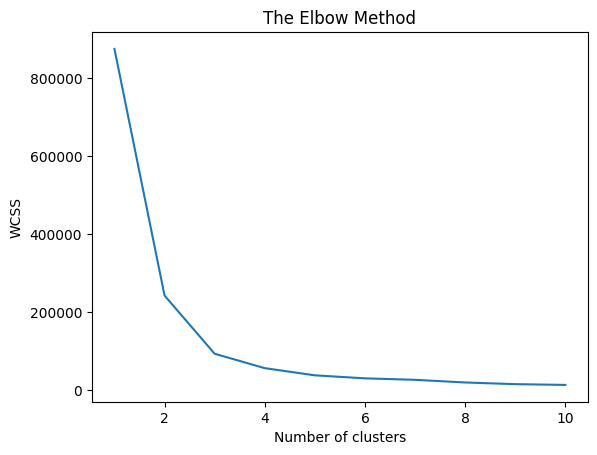

In [54]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [55]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [56]:
y_kmeans

array([0, 2, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 1, 0, 1, 2, 1,
       2, 2, 2, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 1, 2, 2, 1,
       2, 2, 1, 0, 2, 0], dtype=int32)

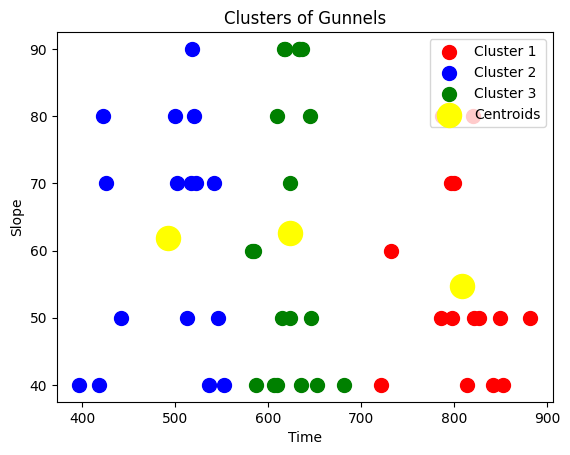

In [57]:
X = X.values
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of Gunnels')
plt.xlabel('Time')
plt.ylabel('Slope')
plt.legend()
plt.show()

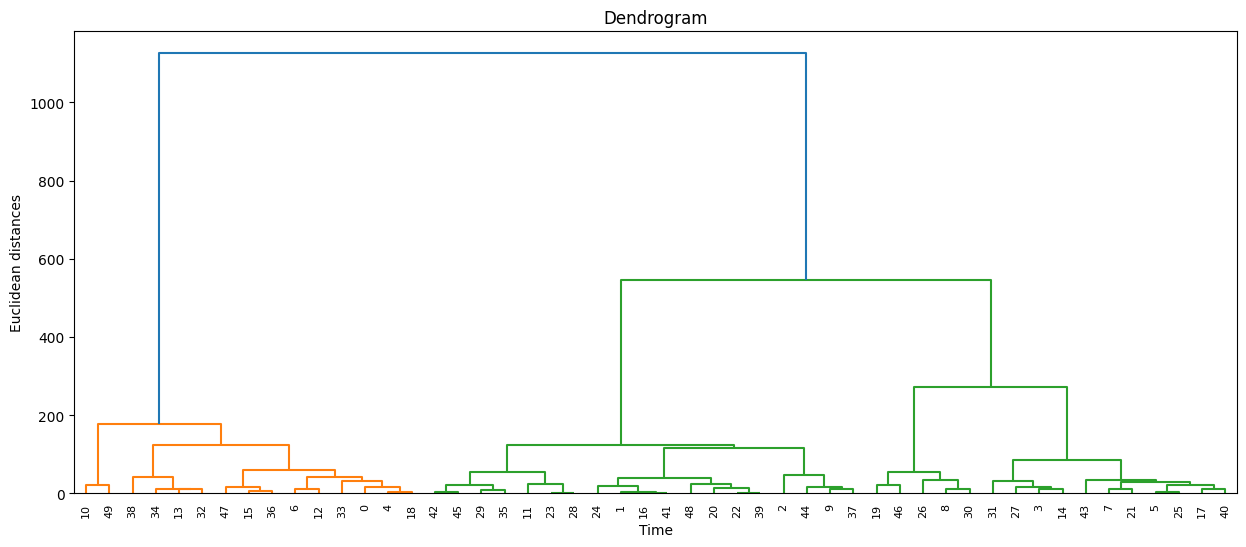

In [58]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15,6))
plt.title('Dendrogram')
plt.xlabel('Time')
plt.ylabel('Euclidean distances')
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()